## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os

OUTPUT_DIR = r'C:\Users\whita\Documents\case-tricura\output_data'

# Style
plt.rcParams.update({
    'figure.figsize': (14, 7),
    'figure.dpi': 120,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

COLORS = ['#2563EB', '#DC2626', '#059669', '#D97706', '#7C3AED', '#DB2777',
          '#0891B2', '#65A30D', '#EA580C', '#4F46E5', '#BE185D', '#0D9488']

print("Setup complete.")

Setup complete.


## 1. Load Data

In [2]:
# Predictions
pred = pd.read_parquet(os.path.join(OUTPUT_DIR, 'predictions_fall.parquet'))

# SHAP — normalized (% contribution)
shap_norm = pd.read_parquet(os.path.join(OUTPUT_DIR, 'shap_normalized_fall.parquet'))

# SHAP — raw (signed)
shap_raw = pd.read_parquet(os.path.join(OUTPUT_DIR, 'shap_raw_fall.parquet'))

# Global SHAP summary
global_shap = pd.read_parquet(os.path.join(OUTPUT_DIR, 'shap_global_fall.parquet'))

# Feature importance
feat_imp = pd.read_parquet(os.path.join(OUTPUT_DIR, 'feature_importance_fall.parquet'))

# Original features for the prediction month
claims_df = pd.read_parquet(os.path.join(OUTPUT_DIR, 'claims_fall_monthly.parquet'))
predict_month = pred['year_month'].iloc[0]
features_df = claims_df[claims_df['year_month'] == predict_month].reset_index(drop=True)

# Identify feature columns (exclude IDs and target)
meta_cols = ['resident_id', 'facility_id', 'year_month', 'claim_type', 
             'y_true', 'y_pred', 'y_proba', 'target_fall']
shap_feat_cols = [c for c in shap_raw.columns if c not in meta_cols]
feat_cols = [c for c in features_df.columns if c not in ['resident_id', 'facility_id', 'year_month', 'target_fall']]

print(f"Predictions: {len(pred)} residents for {predict_month.strftime('%Y-%m')}")
print(f"  Predicted positive: {pred['y_pred'].sum()} ({pred['y_pred'].mean()*100:.1f}%)")
print(f"  Actual positive:    {pred['y_true'].sum()}")
print(f"  Features: {len(shap_feat_cols)}")
print(f"  Probability range: [{pred['y_proba'].min():.4f}, {pred['y_proba'].max():.4f}]")

Predictions: 935 residents for 2025-02
  Predicted positive: 1 (0.1%)
  Actual positive:    0
  Features: 171
  Probability range: [0.0123, 0.5379]


## 2. Probability Distribution

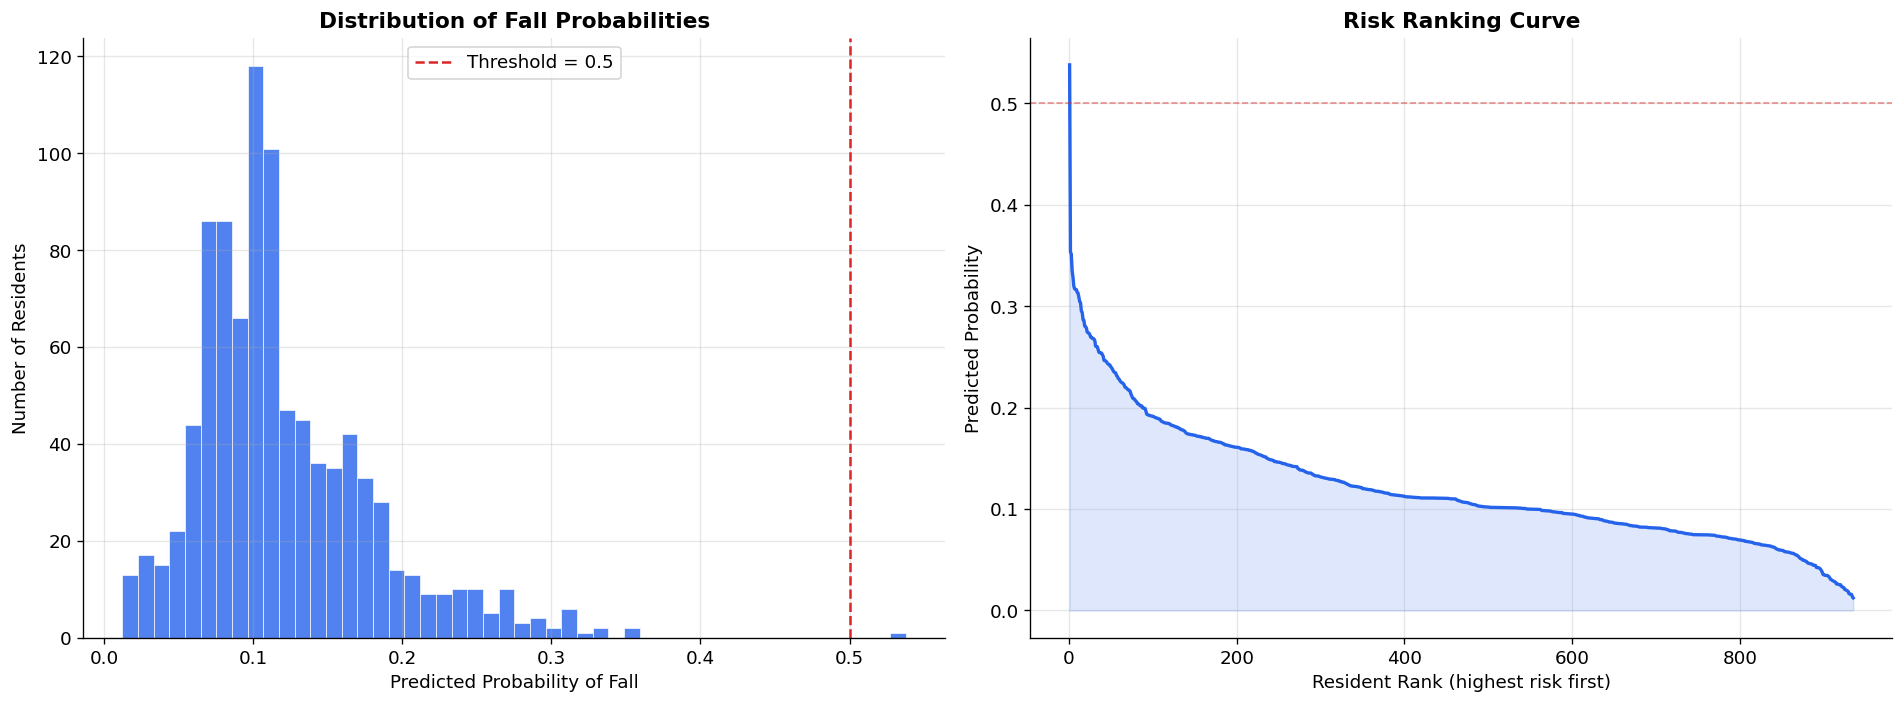


Risk Deciles:
 risk_decile  count  mean_proba  min_proba  max_proba  actual_falls  actual_rate
           1     94    0.041442   0.012342   0.061521             0          0.0
           2     93    0.069653   0.062199   0.074563             0          0.0
           3     94    0.080375   0.074571   0.085728             0          0.0
           4     93    0.093047   0.085788   0.099539             0          0.0
           5     94    0.102036   0.099673   0.107315             0          0.0
           6     93    0.111626   0.107561   0.116219             0          0.0
           7     93    0.125786   0.116573   0.136874             0          0.0
           8     94    0.151079   0.137104   0.163017             0          0.0
           9     93    0.176857   0.163088   0.192500             0          0.0
          10     94    0.251613   0.192993   0.537886             0          0.0


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
ax = axes[0]
ax.hist(pred['y_proba'], bins=50, color=COLORS[0], alpha=0.8, edgecolor='white', linewidth=0.5)
ax.axvline(0.5, color=COLORS[1], linestyle='--', linewidth=1.5, label='Threshold = 0.5')
ax.set_xlabel('Predicted Probability of Fall')
ax.set_ylabel('Number of Residents')
ax.set_title('Distribution of Fall Probabilities', fontweight='bold', fontsize=13)
ax.legend()

# Cumulative
ax = axes[1]
sorted_proba = np.sort(pred['y_proba'])[::-1]
ax.plot(range(1, len(sorted_proba)+1), sorted_proba, color=COLORS[0], linewidth=2)
ax.axhline(0.5, color=COLORS[1], linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Resident Rank (highest risk first)')
ax.set_ylabel('Predicted Probability')
ax.set_title('Risk Ranking Curve', fontweight='bold', fontsize=13)
ax.fill_between(range(1, len(sorted_proba)+1), sorted_proba, alpha=0.15, color=COLORS[0])

plt.tight_layout()
plt.show()

# Stats by decile
pred['risk_decile'] = pd.qcut(pred['y_proba'], 10, labels=False, duplicates='drop') + 1
decile_stats = pred.groupby('risk_decile').agg(
    count=('y_proba', 'count'),
    mean_proba=('y_proba', 'mean'),
    min_proba=('y_proba', 'min'),
    max_proba=('y_proba', 'max'),
    actual_falls=('y_true', 'sum'),
).reset_index()
decile_stats['actual_rate'] = (decile_stats['actual_falls'] / decile_stats['count'] * 100)
print("\nRisk Deciles:")
print(decile_stats.to_string(index=False))

## 3. Top Features — Global SHAP ImportanceMean absolute SHAP value across all residents (normalized to %).

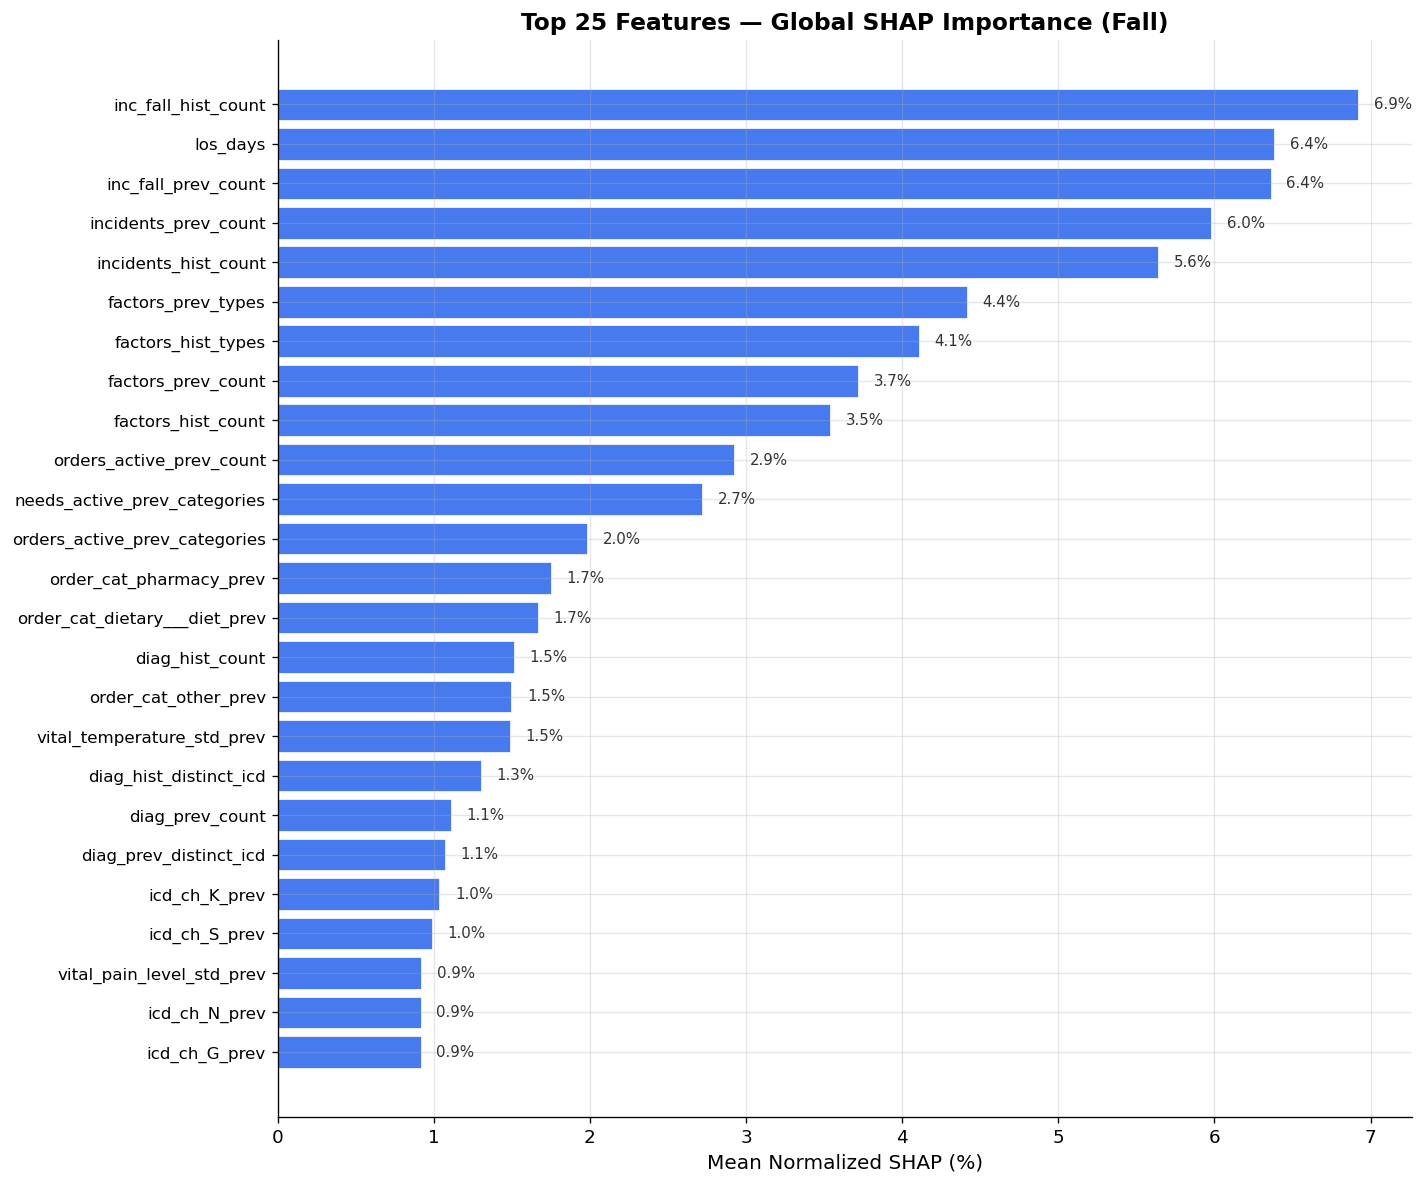

In [4]:
top_n = 25
top_global = global_shap.nlargest(top_n, 'mean_norm_shap_pct')

fig, ax = plt.subplots(figsize=(12, 10))
bars = ax.barh(range(top_n), top_global['mean_norm_shap_pct'].values[::-1], 
               color=COLORS[0], alpha=0.85, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_global['feature'].values[::-1], fontsize=10)
ax.set_xlabel('Mean Normalized SHAP (%)', fontsize=12)
ax.set_title(f'Top {top_n} Features — Global SHAP Importance (Fall)', fontweight='bold', fontsize=14)

# Add value labels
for bar, val in zip(bars, top_global['mean_norm_shap_pct'].values[::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
            f'{val:.1f}%', va='center', fontsize=9, color='#333')

plt.tight_layout()
plt.show()

## 4. Top Features by Probability TierHow do feature importances shift across risk levels?

In [5]:
# Define probability tiers
bins = [0, 0.1, 0.25, 0.5, 0.75, 1.0]
labels = ['Very Low\n(0-10%)', 'Low\n(10-25%)', 'Medium\n(25-50%)', 'High\n(50-75%)', 'Very High\n(75-100%)']
pred['risk_tier'] = pd.cut(pred['y_proba'], bins=bins, labels=labels, include_lowest=True)

print("Residents per tier:")
print(pred['risk_tier'].value_counts().sort_index())
print()

# For each tier, compute mean normalized SHAP and show top features
shap_with_proba = shap_norm.copy()
shap_with_proba['y_proba'] = pred['y_proba'].values
shap_with_proba['risk_tier'] = pred['risk_tier'].values

tier_top_features = {}
for tier in labels:
    subset = shap_with_proba[shap_with_proba['risk_tier'] == tier]
    if len(subset) == 0:
        continue
    mean_shap = subset[shap_feat_cols].mean().sort_values(ascending=False)
    tier_top_features[tier] = mean_shap.head(10)
    print(f"--- {tier.replace(chr(10), ' ')} ({len(subset)} residents) ---")
    for feat, val in mean_shap.head(10).items():
        print(f"  {val:6.2f}%  {feat}")
    print()

Residents per tier:
Very Low\n(0-10%)       390
Low\n(10-25%)           504
Medium\n(25-50%)         40
High\n(50-75%)            1
Very High\n(75-100%)      0
Name: risk_tier, dtype: int64

--- Very Low (0-10%) (390 residents) ---
    7.06%  inc_fall_hist_count
    6.83%  los_days
    6.52%  inc_fall_prev_count
    6.11%  incidents_prev_count
    5.77%  incidents_hist_count
    4.46%  factors_prev_types
    4.15%  factors_hist_types
    3.77%  factors_prev_count
    3.59%  factors_hist_count
    3.04%  orders_active_prev_count

--- Low (10-25%) (504 residents) ---
    6.88%  inc_fall_hist_count
    6.30%  inc_fall_prev_count
    6.25%  los_days
    5.94%  incidents_prev_count
    5.60%  incidents_hist_count
    4.42%  factors_prev_types
    4.11%  factors_hist_types
    3.72%  factors_prev_count
    3.54%  factors_hist_count
    2.77%  orders_active_prev_count

--- Medium (25-50%) (40 residents) ---
    6.13%  inc_fall_hist_count
    5.60%  inc_fall_prev_count
    5.22%  incidents_pre

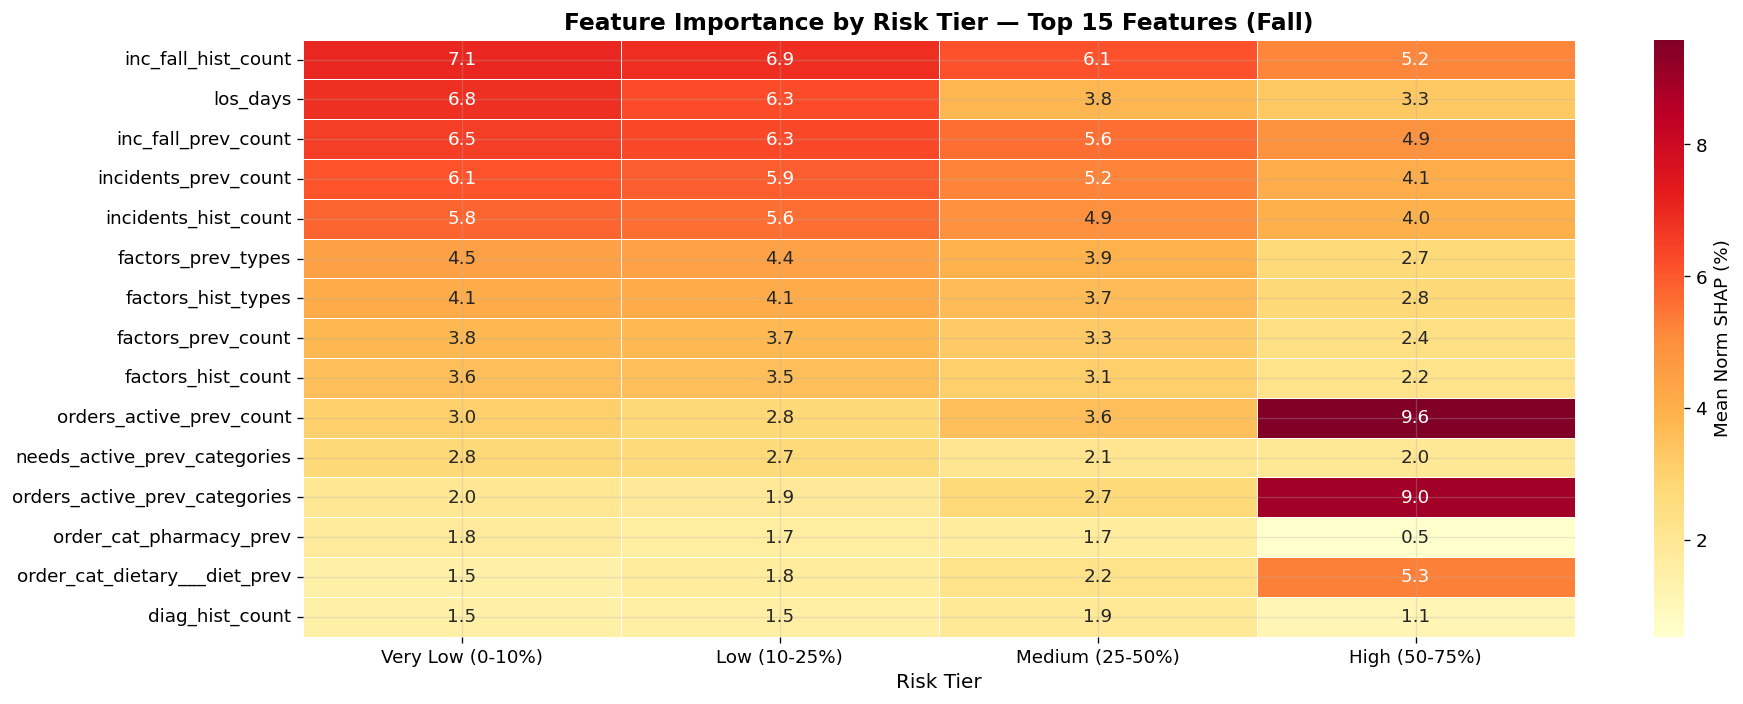

In [6]:
# Heatmap: top 15 features x tiers
top15 = global_shap.nlargest(15, 'mean_norm_shap_pct')['feature'].tolist()

tier_matrix = []
tier_labels_clean = []
for tier in labels:
    subset = shap_with_proba[shap_with_proba['risk_tier'] == tier]
    if len(subset) == 0:
        continue
    tier_labels_clean.append(tier.replace('\n', ' '))
    tier_matrix.append(subset[top15].mean().values)

tier_df = pd.DataFrame(tier_matrix, columns=top15, index=tier_labels_clean)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(tier_df.T, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Mean Norm SHAP (%)'})
ax.set_title('Feature Importance by Risk Tier — Top 15 Features (Fall)', fontweight='bold', fontsize=14)
ax.set_xlabel('Risk Tier', fontsize=12)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 5. Feature Values by Probability TierWhat do the actual feature values look like for high-risk vs low-risk residents?

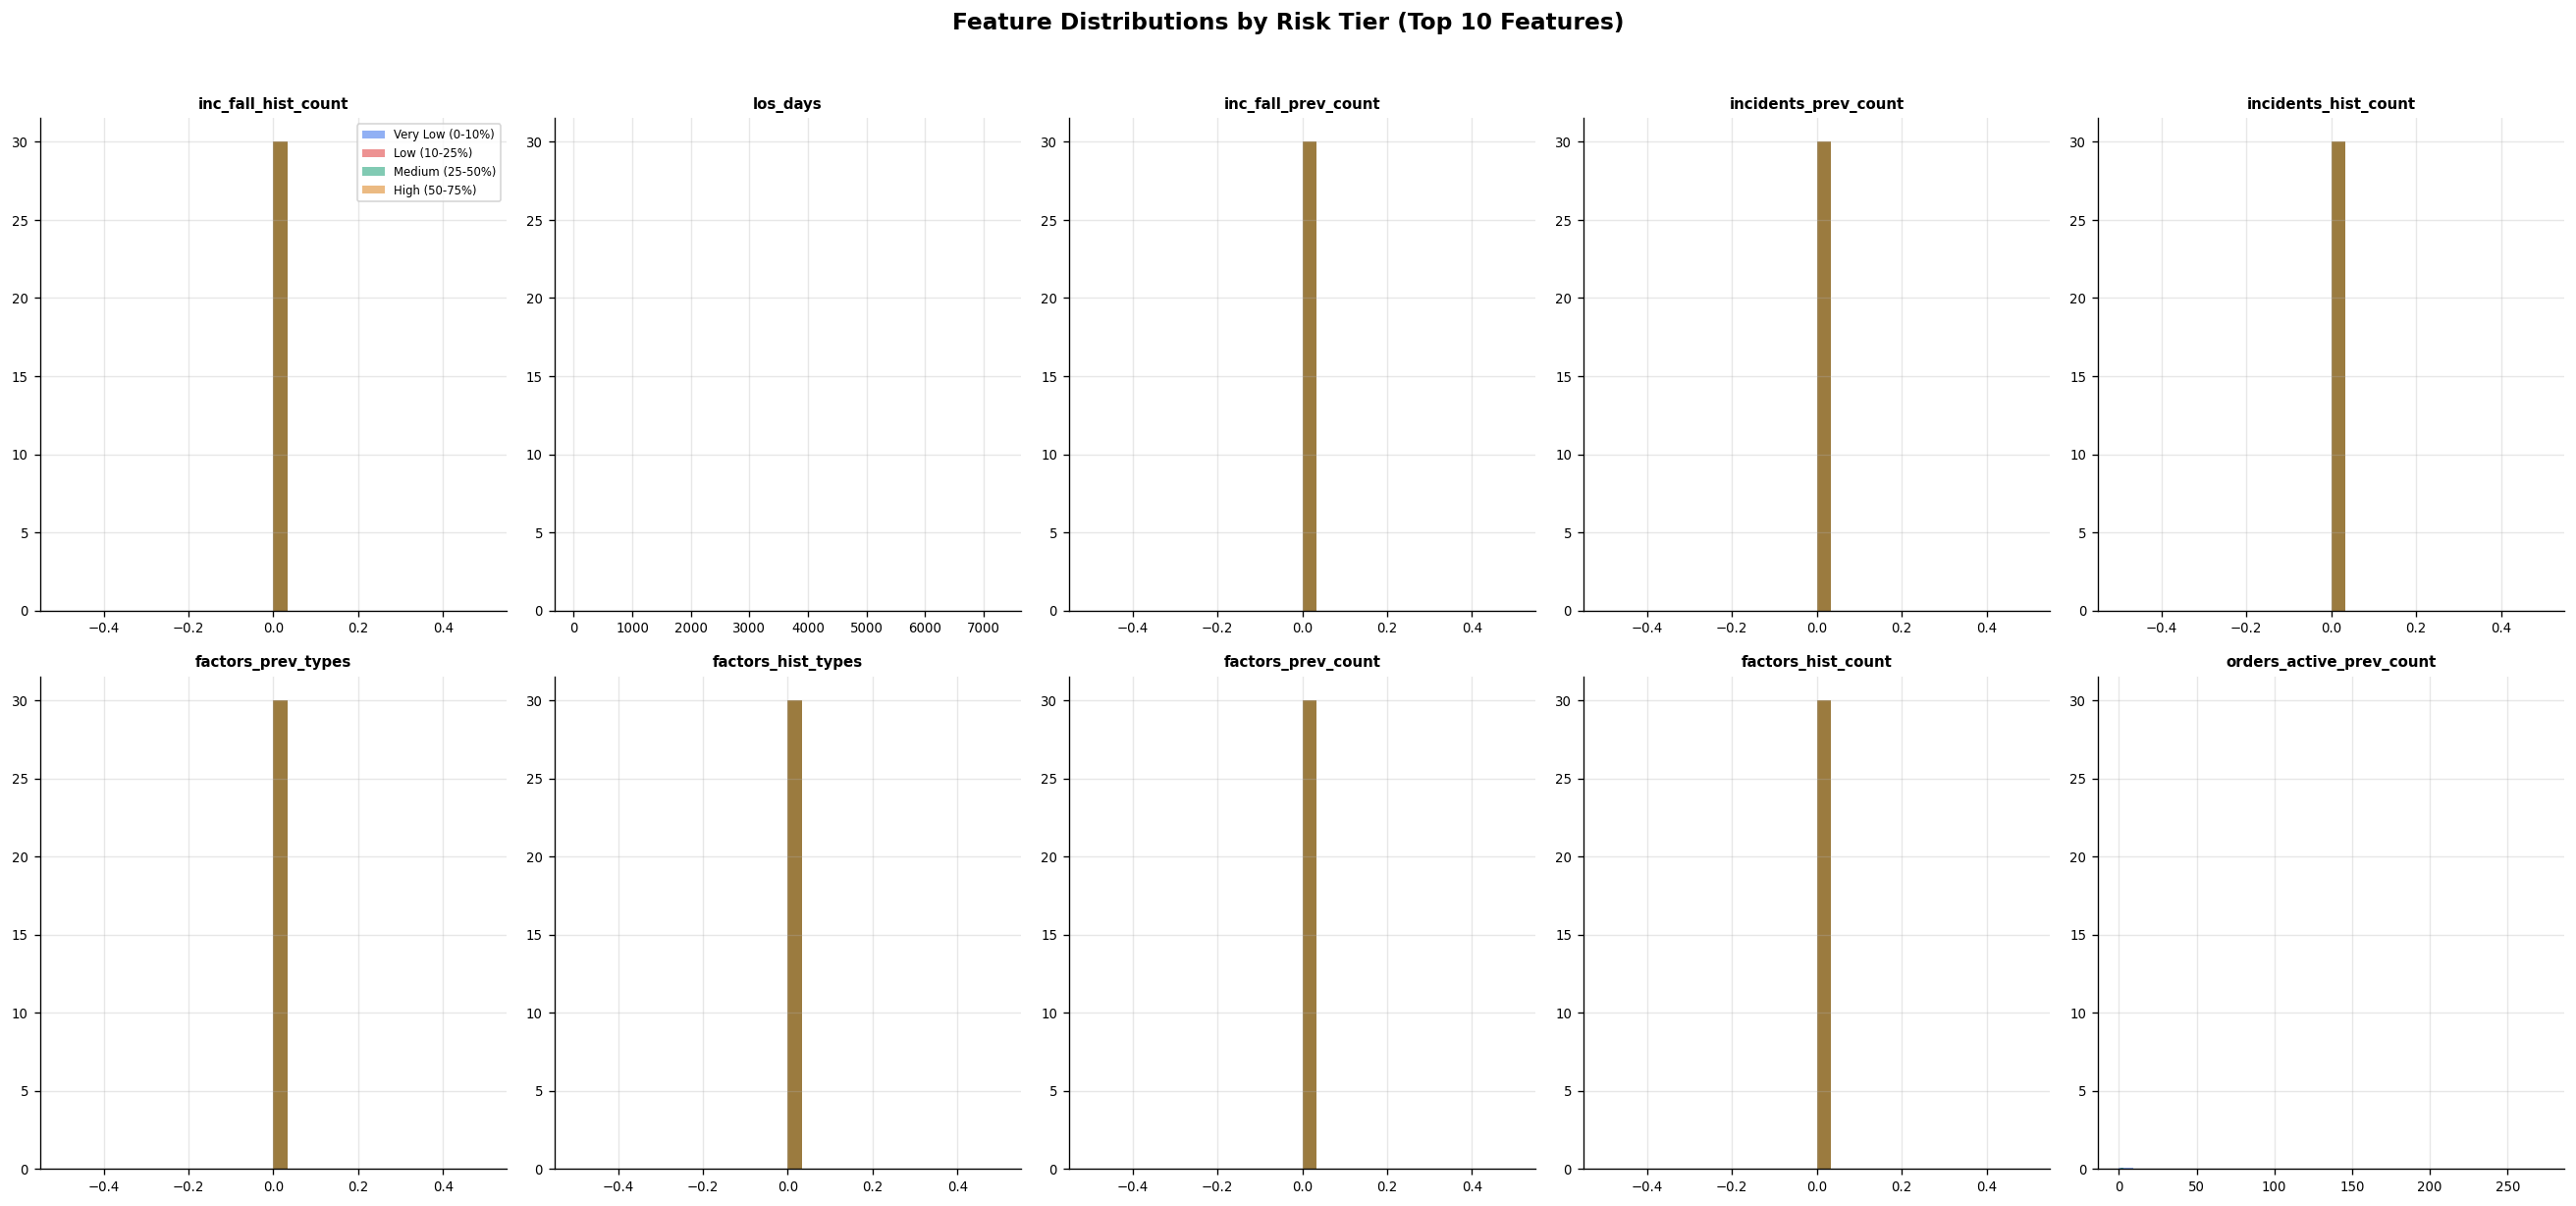

In [7]:
# Merge features with predictions
analysis = pred[['resident_id', 'y_proba', 'y_true', 'risk_tier']].merge(
    features_df, on='resident_id', how='left'
)

# Top 10 global features — show distribution by tier
top10_feats = global_shap.nlargest(10, 'mean_norm_shap_pct')['feature'].tolist()

fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for idx, feat in enumerate(top10_feats):
    ax = axes[idx]
    for i, tier in enumerate(labels):
        subset = analysis[analysis['risk_tier'] == tier]
        if len(subset) == 0 or feat not in subset.columns:
            continue
        vals = subset[feat].dropna()
        if len(vals) > 0:
            ax.hist(vals, bins=30, alpha=0.5, label=tier.replace('\n', ' '), 
                    color=COLORS[i], density=True)
    
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=8)
    if idx == 0:
        ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Feature Distributions by Risk Tier (Top 10 Features)', 
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [8]:
# Summary table: mean feature value by tier for top 15 features
top15_feats = global_shap.nlargest(15, 'mean_norm_shap_pct')['feature'].tolist()
available_feats = [f for f in top15_feats if f in analysis.columns]

tier_means = analysis.groupby('risk_tier')[available_feats].mean()
print("Mean Feature Values by Risk Tier (top 15):\n")
print(tier_means.T.to_string(float_format='{:.2f}'.format))

Mean Feature Values by Risk Tier (top 15):

risk_tier                      Very Low\n(0-10%)  Low\n(10-25%)  Medium\n(25-50%)  High\n(50-75%)  Very High\n(75-100%)
inc_fall_hist_count                         0.00           0.00              0.00            0.00                   NaN
los_days                                  801.34         610.45            274.27          458.00                   NaN
inc_fall_prev_count                         0.00           0.00              0.00            0.00                   NaN
incidents_prev_count                        0.00           0.00              0.00            0.00                   NaN
incidents_hist_count                        0.00           0.00              0.00            0.00                   NaN
factors_prev_types                          0.00           0.00              0.00            0.00                   NaN
factors_hist_types                          0.00           0.00              0.00            0.00                   

## 6. SHAP vs Probability — Colored by FeatureFor each of the top features: how does its SHAP value relate to the predicted probability?

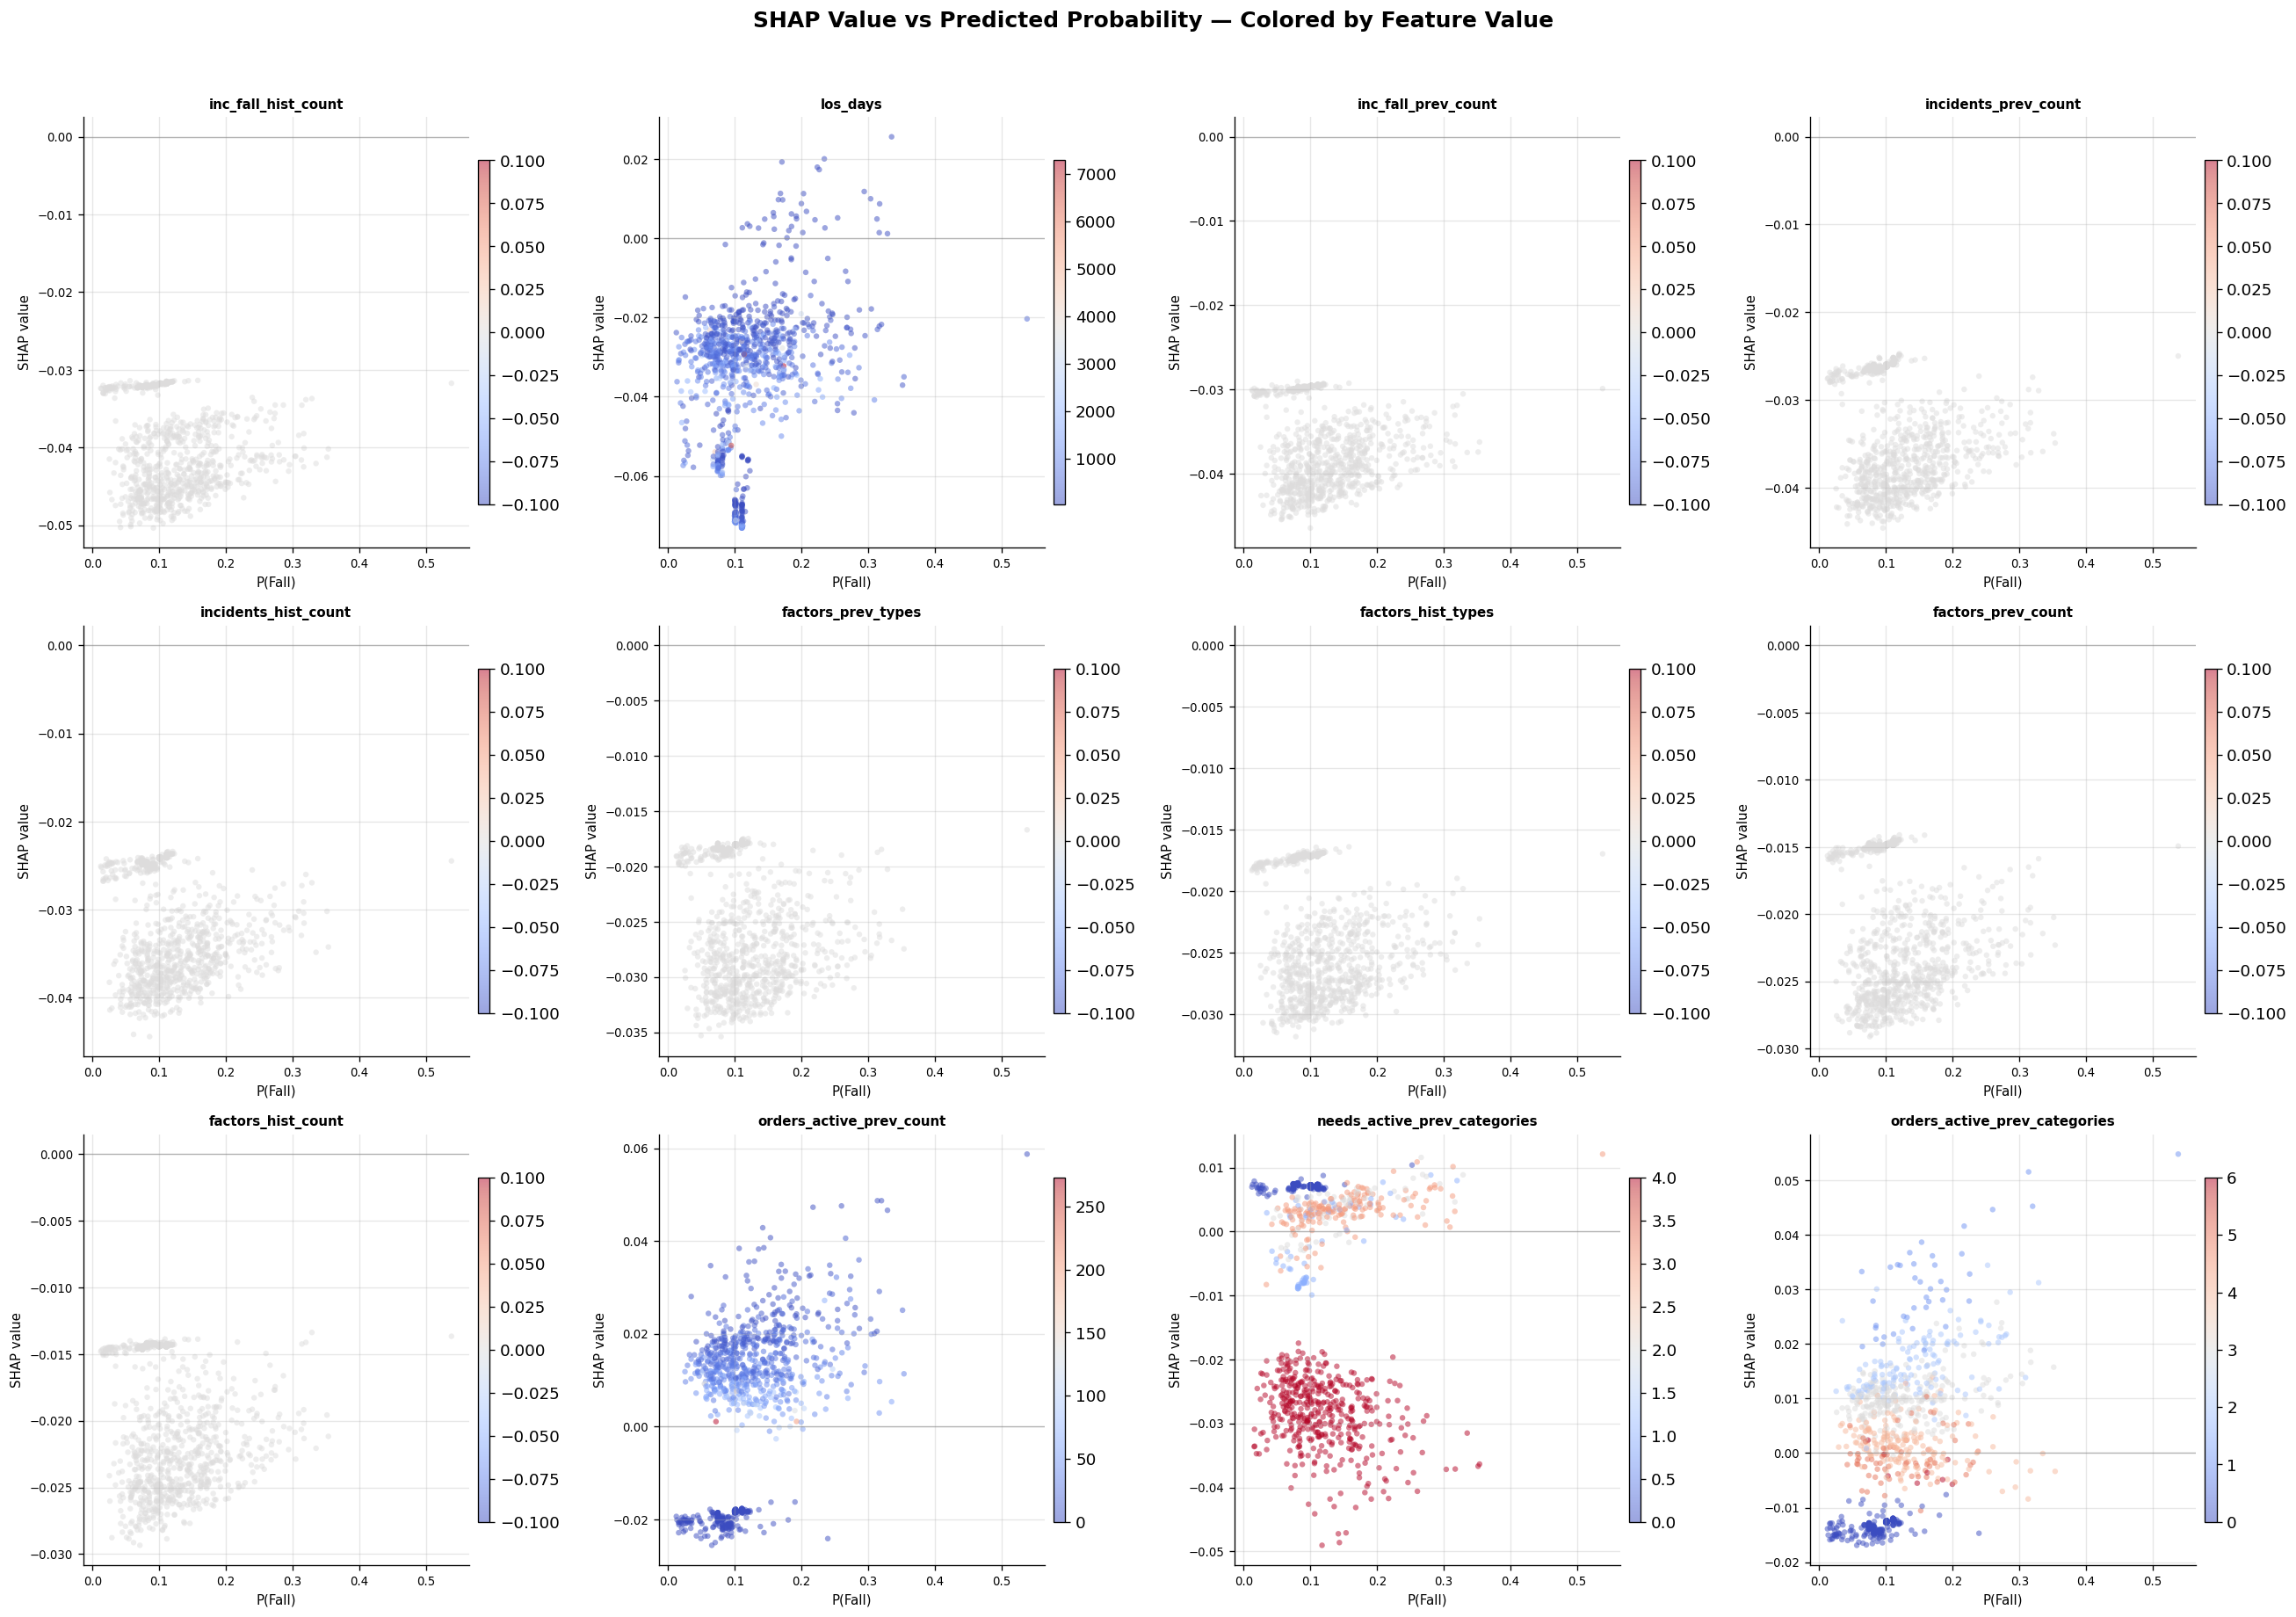

In [9]:
# Build long-format dataframe: (resident, feature, shap_value, probability)
top12_feats = global_shap.nlargest(12, 'mean_norm_shap_pct')['feature'].tolist()

shap_raw_vals = shap_raw[shap_feat_cols].copy()
shap_raw_vals['y_proba'] = pred['y_proba'].values

fig, axes = plt.subplots(3, 4, figsize=(22, 15))
axes = axes.flatten()

for idx, feat in enumerate(top12_feats):
    ax = axes[idx]
    
    x = shap_raw_vals['y_proba'].values
    y = shap_raw_vals[feat].values
    
    # Color by feature value
    if feat in features_df.columns:
        c = features_df[feat].values
        sc = ax.scatter(x, y, c=c, cmap='coolwarm', alpha=0.5, s=15, edgecolors='none')
        plt.colorbar(sc, ax=ax, pad=0.02, aspect=30, shrink=0.8)
    else:
        ax.scatter(x, y, alpha=0.4, s=15, color=COLORS[0], edgecolors='none')
    
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='-', alpha=0.5)
    ax.set_xlabel('P(Fall)', fontsize=9)
    ax.set_ylabel('SHAP value', fontsize=9)
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=8)

plt.suptitle('SHAP Value vs Predicted Probability — Colored by Feature Value',
             fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 7. Combined SHAP Beeswarm — All Features on One ChartEach dot = one resident. X = SHAP value. Color = feature value. Sorted by importance.

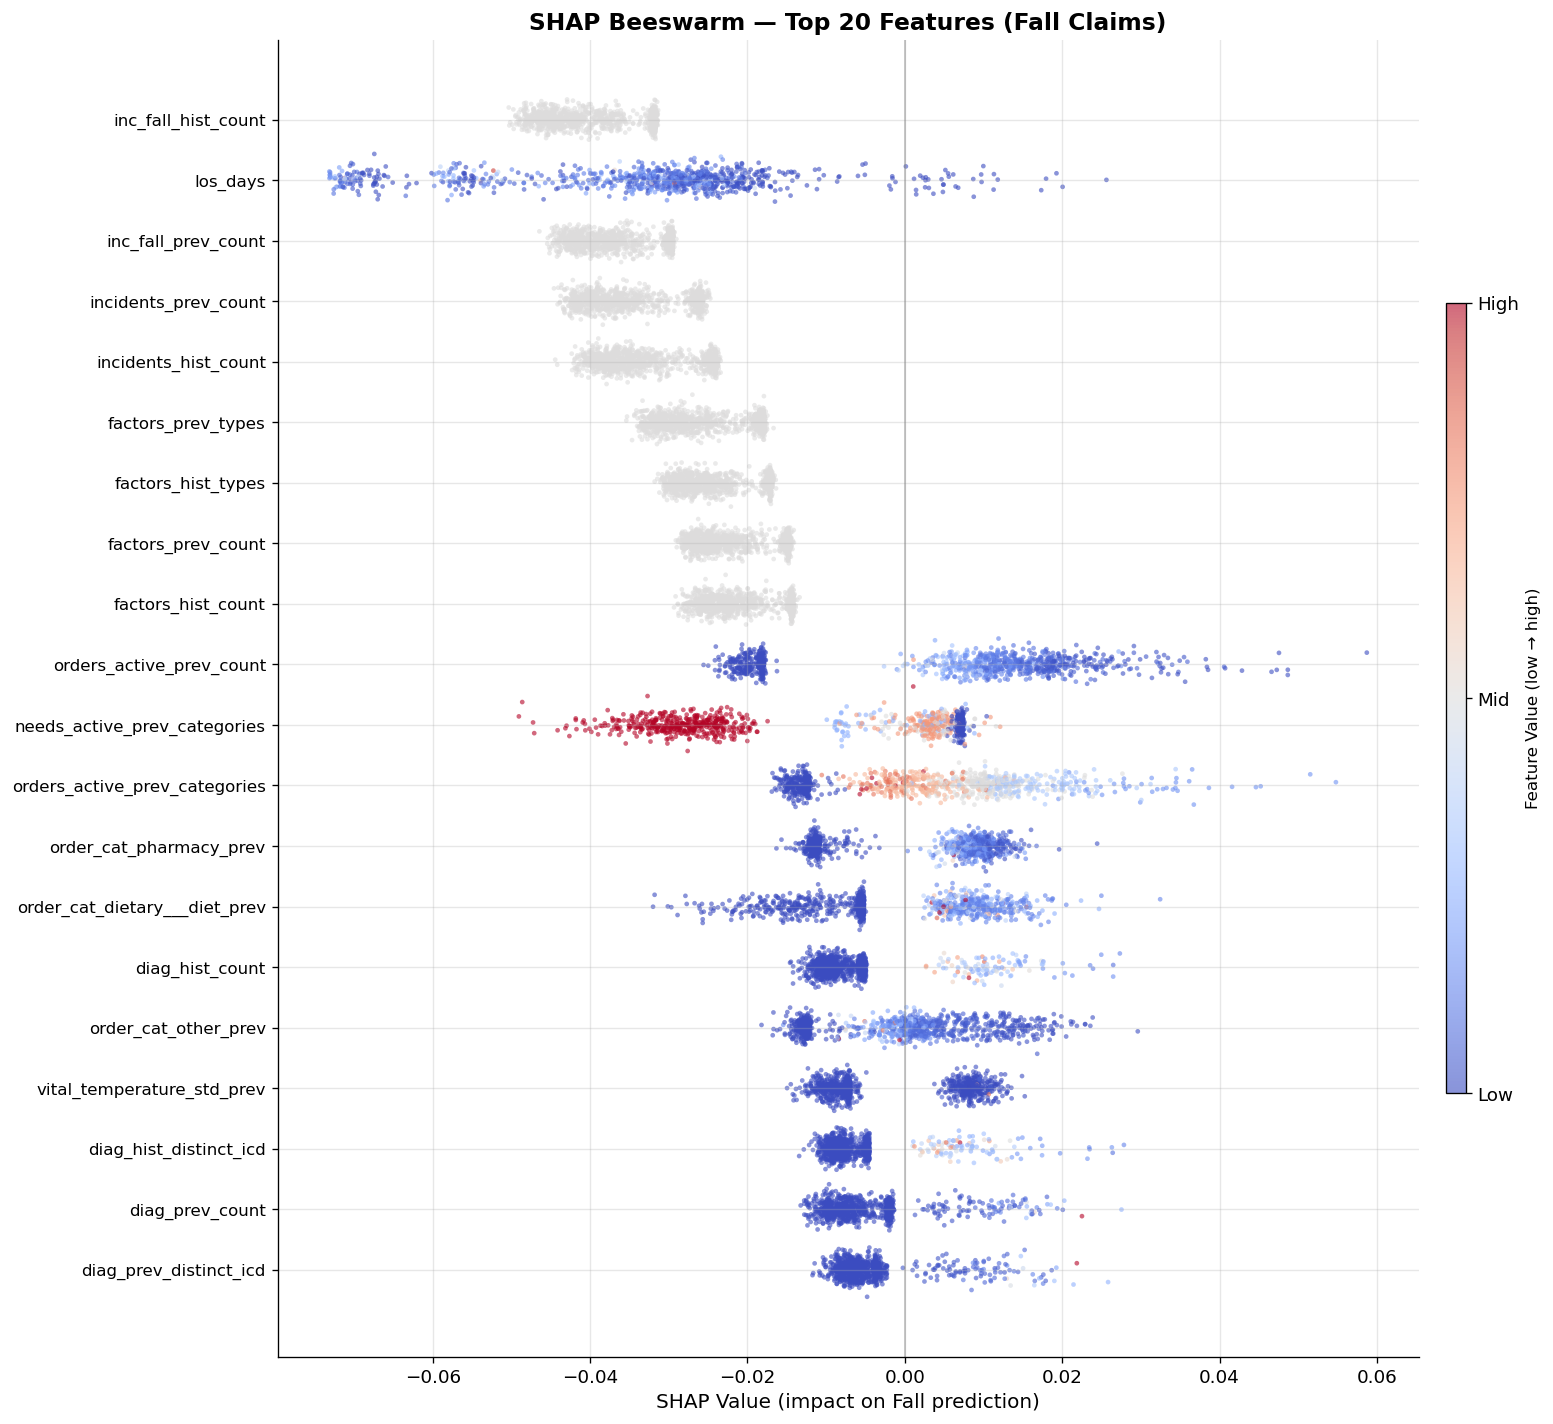

In [10]:
top20_feats = global_shap.nlargest(20, 'mean_norm_shap_pct')['feature'].tolist()

fig, ax = plt.subplots(figsize=(14, 12))

for rank, feat in enumerate(top20_feats[::-1]):  # reverse so top feature is at top
    shap_vals = shap_raw[feat].values
    
    if feat in features_df.columns:
        feat_vals = features_df[feat].values
        # Normalize feature values to [0,1] for color
        fmin, fmax = np.nanmin(feat_vals), np.nanmax(feat_vals)
        if fmax > fmin:
            feat_norm = (feat_vals - fmin) / (fmax - fmin)
        else:
            feat_norm = np.full_like(feat_vals, 0.5)
    else:
        feat_norm = np.full(len(shap_vals), 0.5)
    
    # Add jitter on y
    jitter = np.random.normal(0, 0.12, size=len(shap_vals))
    
    sc = ax.scatter(shap_vals, rank + jitter, c=feat_norm, cmap='coolwarm',
                    s=8, alpha=0.6, edgecolors='none', vmin=0, vmax=1)

ax.set_yticks(range(len(top20_feats)))
ax.set_yticklabels(top20_feats[::-1], fontsize=10)
ax.axvline(0, color='gray', linewidth=1, alpha=0.5)
ax.set_xlabel('SHAP Value (impact on Fall prediction)', fontsize=12)
ax.set_title('SHAP Beeswarm — Top 20 Features (Fall Claims)', fontweight='bold', fontsize=14)

cbar = plt.colorbar(sc, ax=ax, pad=0.02, aspect=40, shrink=0.6)
cbar.set_label('Feature Value (low → high)', fontsize=10)
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(['Low', 'Mid', 'High'])

plt.tight_layout()
plt.show()

## 8. SHAP Waterfall — Top 10 Highest Risk PatientsIndividual patient breakdown showing which features push the prediction up or down.

In [15]:
patient_shap_raw

age_years                      0.001699
los_days                      -0.020336
is_outpatient                  0.000810
incidents_hist_count          -0.024477
incidents_prev_count          -0.024991
                                 ...   
doctags_hist_types             0.000207
doctags_hist_avg_confidence   -0.000004
doctags_prev_count            -0.000031
doctags_prev_types             0.000041
doctags_prev_avg_confidence    0.000030
Name: 113, Length: 171, dtype: float64

In [16]:
# Top 10 highest risk
top10_patients = pred.nlargest(10, 'y_proba')

for rank, (idx, row) in enumerate(top10_patients.iterrows()):
    print(f"\n{'='*60}")
    print(f"  #{rank+1} — Resident: {row['resident_id'][:12]}...")
    print(f"  Probability: {row['y_proba']:.4f}  |  Actual: {'FALL' if row['y_true']==1 else 'No fall'}")
    print(f"{'='*60}")
    
    # Get this patient's SHAP values (raw, signed)
    patient_shap_raw = shap_raw.loc[idx, shap_feat_cols]
    patient_shap_norm = shap_norm.loc[idx, shap_feat_cols]
    
    # Top positive and negative contributors
    top_pos = patient_shap_raw.astype(float).nlargest(8)
    top_neg = patient_shap_raw.astype(float).nsmallest(5)
    
    print(f"\n  Top POSITIVE contributors (push toward Fall):")
    for feat, val in top_pos.items():
        feat_val = features_df.loc[idx, feat] if feat in features_df.columns else 'N/A'
        pct = patient_shap_norm.get(feat, 0)
        print(f"    SHAP={val:+.4f} ({pct:.1f}%)  [{feat}={feat_val}]")
    
    print(f"\n  Top NEGATIVE contributors (push away from Fall):")
    for feat, val in top_neg.items():
        feat_val = features_df.loc[idx, feat] if feat in features_df.columns else 'N/A'
        pct = patient_shap_norm.get(feat, 0)
        print(f"    SHAP={val:+.4f} ({pct:.1f}%)  [{feat}={feat_val}]")


  #1 — Resident: 1c9e4872-cec...
  Probability: 0.5379  |  Actual: No fall

  Top POSITIVE contributors (push toward Fall):
    SHAP=+0.0587 (9.6%)  [orders_active_prev_count=1.0]
    SHAP=+0.0548 (9.0%)  [orders_active_prev_categories=1.0]
    SHAP=+0.0325 (5.3%)  [order_cat_dietary___diet_prev=1.0]
    SHAP=+0.0162 (2.6%)  [need_cat_fall_prev=3.0]
    SHAP=+0.0147 (2.4%)  [need_cat_other_prev=3.0]
    SHAP=+0.0141 (2.3%)  [needs_active_prev_types=4.0]
    SHAP=+0.0121 (2.0%)  [needs_active_prev_categories=3.0]
    SHAP=+0.0118 (1.9%)  [icd_ch_E_prev=1.0]

  Top NEGATIVE contributors (push away from Fall):
    SHAP=-0.0317 (5.2%)  [inc_fall_hist_count=0.0]
    SHAP=-0.0299 (4.9%)  [inc_fall_prev_count=0.0]
    SHAP=-0.0250 (4.1%)  [incidents_prev_count=0.0]
    SHAP=-0.0245 (4.0%)  [incidents_hist_count=0.0]
    SHAP=-0.0203 (3.3%)  [los_days=458]

  #2 — Resident: b8864597-77c...
  Probability: 0.3534  |  Actual: No fall

  Top POSITIVE contributors (push toward Fall):
    SHAP=+0.0

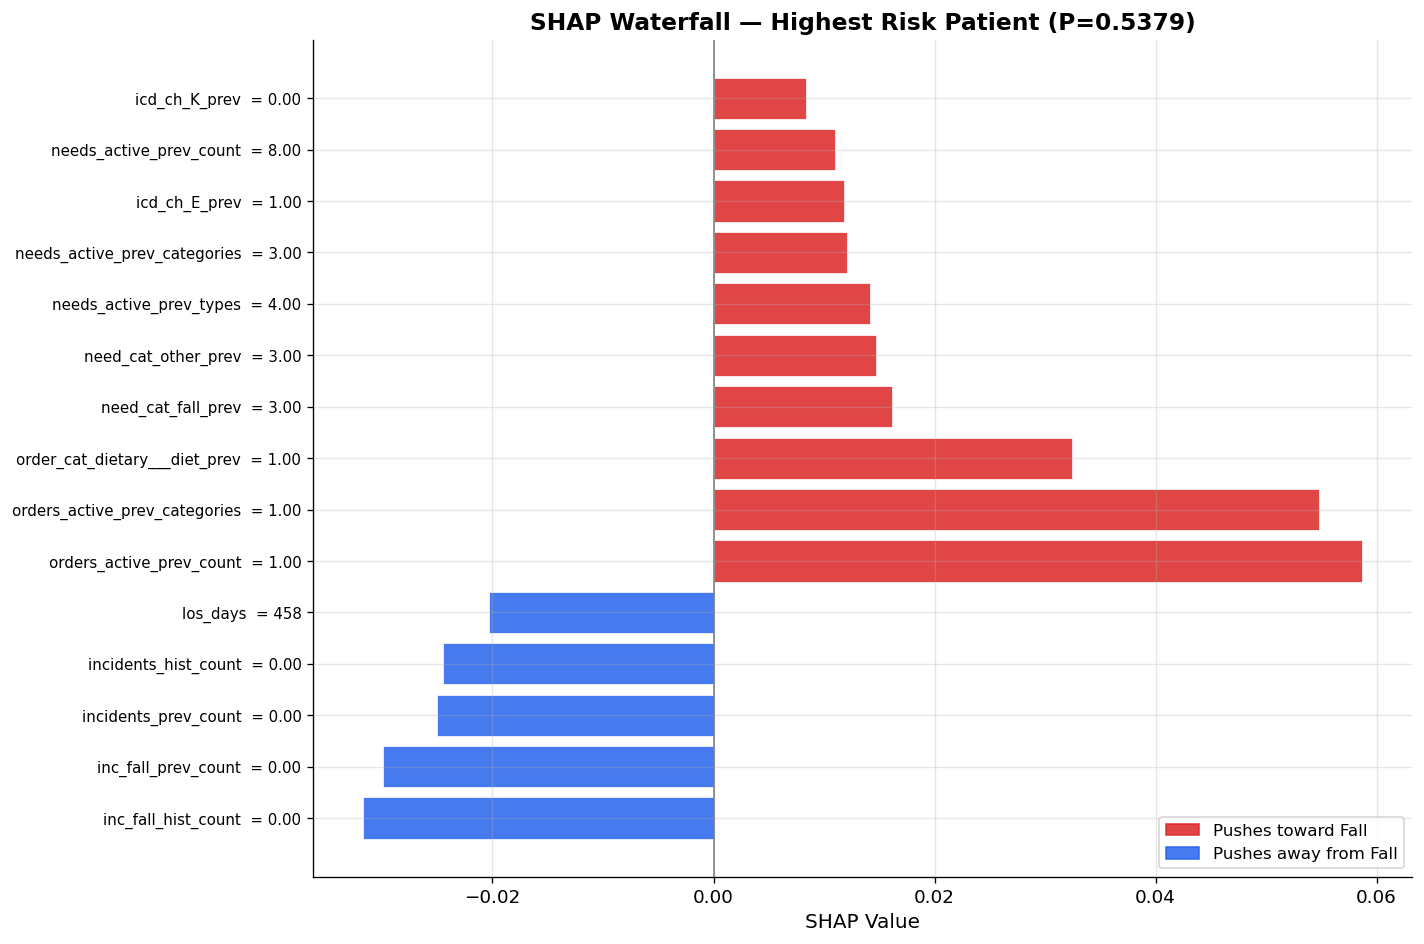

In [18]:
# Waterfall chart for the #1 highest risk patient
top_idx = pred['y_proba'].idxmax()
patient_shap = shap_raw.loc[top_idx, shap_feat_cols].sort_values()

# Take top 10 positive + top 5 negative
top_pos = patient_shap.astype(float).nlargest(10)
top_neg = patient_shap.astype(float).nsmallest(5)
selected = pd.concat([top_neg, top_pos])

fig, ax = plt.subplots(figsize=(12, 8))
colors = [COLORS[1] if v > 0 else COLORS[0] for v in selected.values]
bars = ax.barh(range(len(selected)), selected.values, color=colors, alpha=0.85, 
               edgecolor='white', linewidth=0.5)

ax.set_yticks(range(len(selected)))
ylabels = []
for feat in selected.index:
    feat_val = features_df.loc[top_idx, feat] if feat in features_df.columns else '?'
    if isinstance(feat_val, float):
        ylabels.append(f"{feat}  = {feat_val:.2f}")
    else:
        ylabels.append(f"{feat}  = {feat_val}")

ax.set_yticklabels(ylabels, fontsize=9)
ax.axvline(0, color='gray', linewidth=1)
ax.set_xlabel('SHAP Value', fontsize=12)
ax.set_title(f'SHAP Waterfall — Highest Risk Patient (P={pred.loc[top_idx, "y_proba"]:.4f})',
             fontweight='bold', fontsize=14)

# Legend
from matplotlib.patches import Patch
ax.legend([Patch(color=COLORS[1], alpha=0.85), Patch(color=COLORS[0], alpha=0.85)],
          ['Pushes toward Fall', 'Pushes away from Fall'], loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

## 9. Feature Interaction — SHAP Dependence PlotsFor the top 4 features: how does the SHAP value change with feature value, colored by the strongest interacting feature?

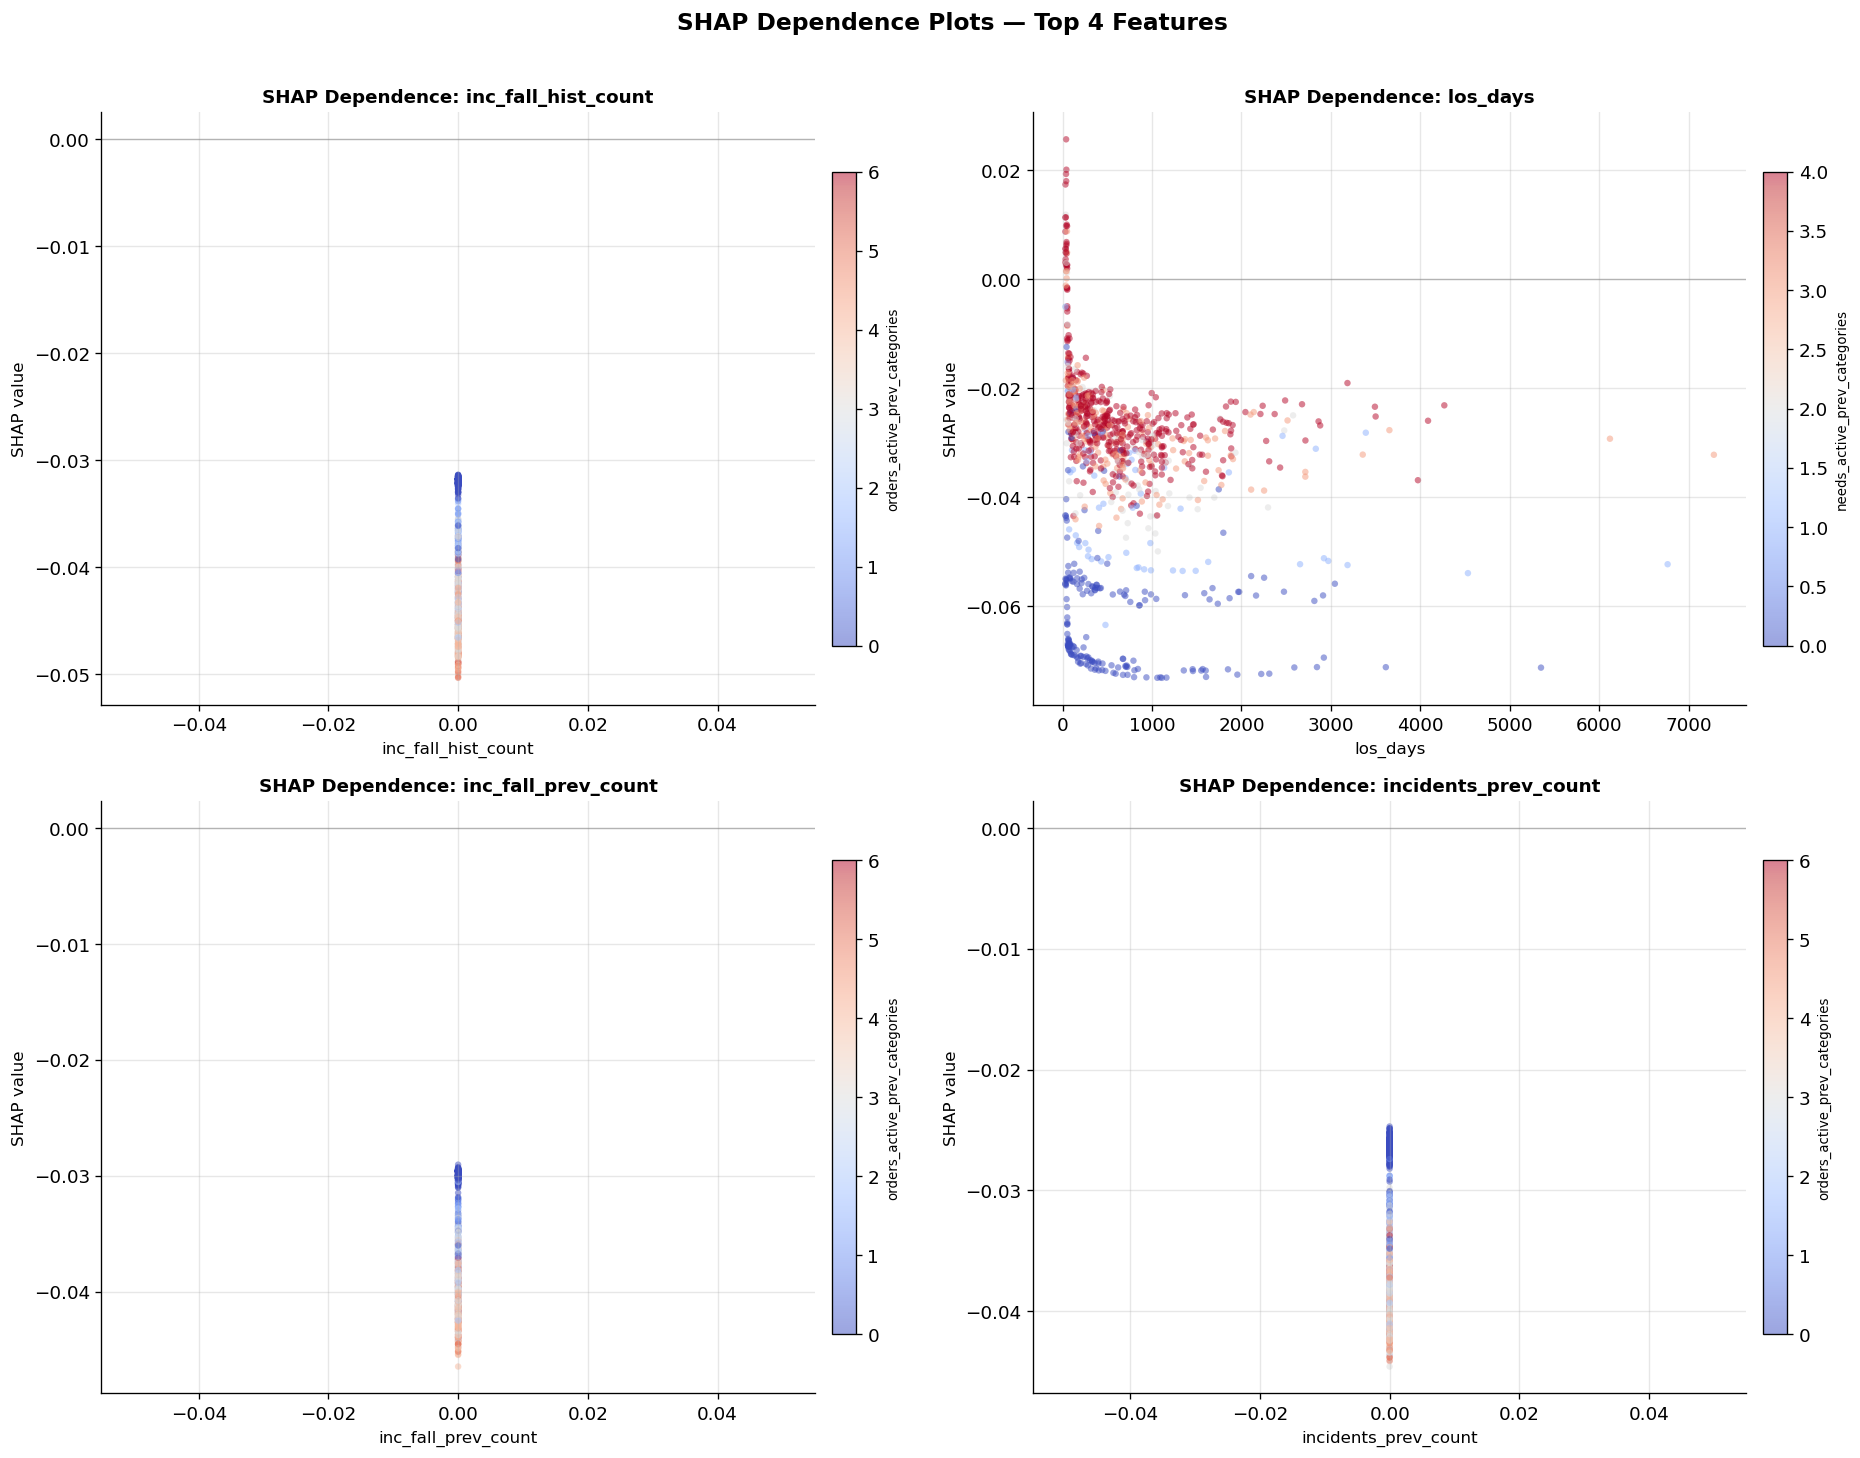

In [19]:
top4 = global_shap.nlargest(4, 'mean_norm_shap_pct')['feature'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, feat in enumerate(top4):
    ax = axes[idx]
    
    if feat not in features_df.columns:
        ax.set_title(f'{feat} (not in features)', fontsize=10)
        continue
    
    feat_values = features_df[feat].values
    shap_vals = shap_raw[feat].values
    
    # Find strongest interaction: feature with highest correlation to |SHAP - E[SHAP|feat]|
    # Simple approach: use the feature with highest abs correlation to the SHAP residuals
    best_interact_feat = None
    best_corr = 0
    for other_feat in top15_feats:
        if other_feat == feat or other_feat not in features_df.columns:
            continue
        other_vals = features_df[other_feat].values
        if np.std(other_vals) > 0:
            corr = abs(np.corrcoef(other_vals, shap_vals)[0, 1])
            if not np.isnan(corr) and corr > best_corr:
                best_corr = corr
                best_interact_feat = other_feat
    
    if best_interact_feat and best_interact_feat in features_df.columns:
        color_vals = features_df[best_interact_feat].values
        sc = ax.scatter(feat_values, shap_vals, c=color_vals, cmap='coolwarm', 
                       s=15, alpha=0.5, edgecolors='none')
        cbar = plt.colorbar(sc, ax=ax, pad=0.02, shrink=0.8)
        cbar.set_label(best_interact_feat, fontsize=8)
    else:
        ax.scatter(feat_values, shap_vals, s=15, alpha=0.4, color=COLORS[0], edgecolors='none')
    
    ax.axhline(0, color='gray', linewidth=0.8, alpha=0.5)
    ax.set_xlabel(f'{feat}', fontsize=10)
    ax.set_ylabel('SHAP value', fontsize=10)
    ax.set_title(f'SHAP Dependence: {feat}', fontweight='bold', fontsize=11)

plt.suptitle('SHAP Dependence Plots — Top 4 Features', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 10. Summary Statistics

In [20]:
print("=" * 60)
print("  FALL PREDICTION MODEL — SUMMARY")
print("=" * 60)

print(f"\n  Prediction month: {predict_month.strftime('%Y-%m')}")
print(f"  Total residents:  {len(pred):,}")
print(f"  Actual falls:     {int(pred['y_true'].sum())}")
print(f"  Predicted falls:  {int(pred['y_pred'].sum())}")

print(f"\n  Probability distribution:")
for pct in [10, 25, 50, 75, 90, 95, 99]:
    val = np.percentile(pred['y_proba'], pct)
    print(f"    P{pct:2d}: {val:.4f}")

print(f"\n  Top 5 most important features (normalized SHAP %):")
for _, row in global_shap.head(5).iterrows():
    print(f"    {row['mean_norm_shap_pct']:6.2f}%  {row['feature']}")

# High risk residents
high_risk = pred[pred['y_proba'] >= 0.5]
print(f"\n  High risk residents (P >= 0.5): {len(high_risk)}")
if len(high_risk) > 0:
    print(f"    Actual falls among them: {int(high_risk['y_true'].sum())} ({high_risk['y_true'].mean()*100:.1f}%)")

print(f"\n  Done! All charts above ready for analysis.")

  FALL PREDICTION MODEL — SUMMARY

  Prediction month: 2025-02
  Total residents:  935
  Actual falls:     0
  Predicted falls:  1

  Probability distribution:
    P10: 0.0618
    P25: 0.0811
    P50: 0.1073
    P75: 0.1513
    P90: 0.1928
    P95: 0.2424
    P99: 0.3135

  Top 5 most important features (normalized SHAP %):
      6.92%  inc_fall_hist_count
      6.36%  inc_fall_prev_count
      5.98%  incidents_prev_count
      6.38%  los_days
      5.64%  incidents_hist_count

  High risk residents (P >= 0.5): 1
    Actual falls among them: 0 (0.0%)

  Done! All charts above ready for analysis.
